Cell 1: Data Load

In [21]:
import seaborn as sns
import torch

df=sns.load_dataset("iris")

print(df.head());
print('------------------\n')
print(df.describe());
print('------------------\n')
print(df.info());
print('------------------\n')
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
print('------------------\n')

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
------------------

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000
------------------

<class 'pandas.DataFrame'>
RangeInde

Cell 2: Feature Distribution

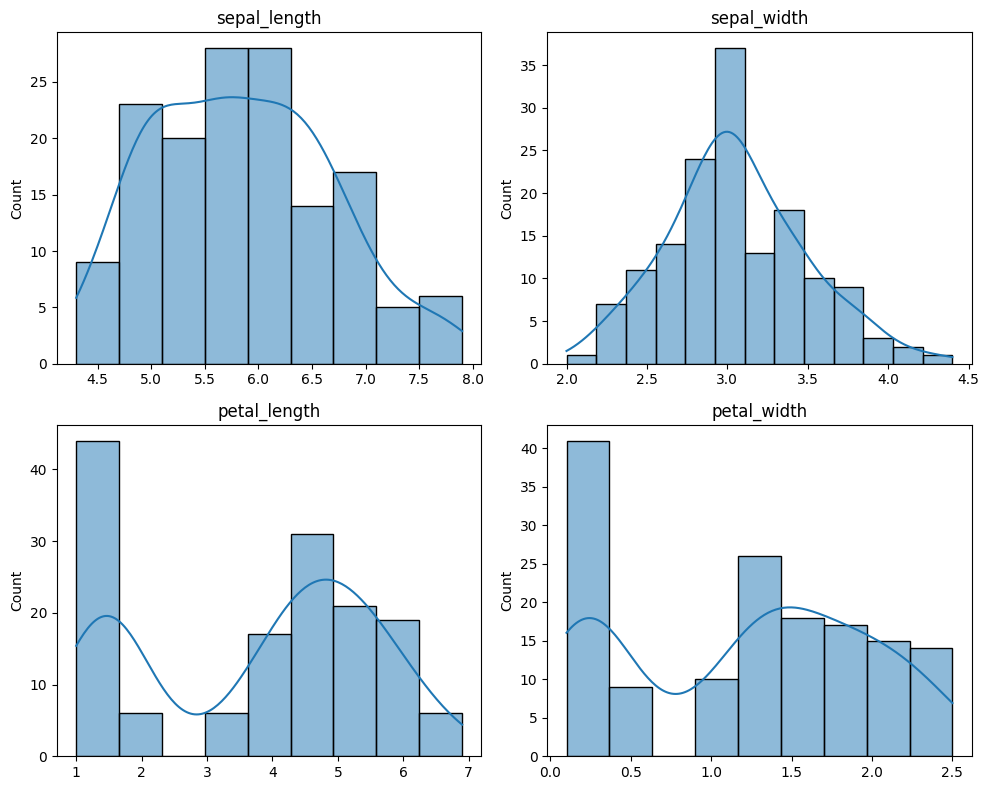

In [22]:
import matplotlib.pyplot as plt

features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
#returns 2d array [[ax0,ax1],[ax2,ax3]]
fig, axes = plt.subplots(2,2, figsize=(10,8))
#returns flat array [ax0,ax1,ax2,ax3]
axes = axes.flatten()

for ax, feature in zip(axes, features):
    #histogram with kde (kernel density estimation) to show distribution of the feature
    sns.histplot(df[feature], kde=True, ax=ax)
    ax.set_title(feature)
    ax.set_xlabel('')

plt.tight_layout()


Cell 3: Feature Encoding

In [23]:
#Converts the DataFrame into a NumPy array
X=df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']].values.astype('float32');
print(X[:5])
y=df['species'].astype('category').cat.codes.values.astype('int64')
print(y[:])

print(f"Dataset: {df.shape[0]} samples, {df.shape[1]} features, {len(df['species'].unique())} classes")

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
Dataset: 150 samples, 5 features, 3 classes


Cell 4: K-Fold Cross Validation Setup

In [24]:
import torch
import numpy as np
from sklearn.model_selection import StratifiedKFold

# Factory function — call once per fold to get a fresh, randomly-initialized model.
# Critical: reusing the same model across folds would leak learned weights.
def create_model():
    return torch.nn.Sequential(
        torch.nn.Linear(4, 16),
        torch.nn.ReLU(),
        torch.nn.Linear(16, 3)
    )

K = 5

skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

print(f"K-Fold Cross Validation: K={K}")
print(f"Approx per fold — train: {len(X) - len(X)//K} samples, val: {len(X)//K} samples")

K-Fold Cross Validation: K=5
Approx per fold — train: 120 samples, val: 30 samples


Cell 5: K-Fold Training Loop

In [25]:
# fold_results stores per-fold metrics and predictions for later analysis.
fold_results = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X,y)):
    # --- Data for this fold ---
    X_train_f = torch.tensor(X[train_idx])
    y_train_f = torch.tensor(y[train_idx])

    X_test_f = torch.tensor(X[test_idx])
    y_test_f = torch.tensor(y[test_idx])

    train_dataset = torch.utils.data.TensorDataset(X_train_f, y_train_f)
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size = 16, shuffle=True)
    
    # --- Fresh model, criterion, optimizer per fold ---
    model = create_model()
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    # --- Training ---
    model.train()
    for epoch in range(100):
        for X_batch, y_batch in train_dataloader:
            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

    # --- Testing ---
    model.eval()
    with torch.no_grad():
        outputs = model(X_test_f)
        preds   = torch.argmax(outputs, dim=1)
        acc     = (preds == y_test_f).float().mean().item()

    fold_results.append({
        'fold':       fold + 1,
        'accuracy':   acc,
        'final_loss': loss.item(),
        'preds':      preds.numpy(),
        'targets':    y_test_f.numpy()
    })
    print(f"Fold {fold+1}/{K}  —  test accuracy: {acc:.4f},  final loss: {loss.item():.4f}")

Fold 1/5  —  test accuracy: 1.0000,  final loss: 0.0008
Fold 2/5  —  test accuracy: 1.0000,  final loss: 0.0021
Fold 3/5  —  test accuracy: 0.9000,  final loss: 0.0170
Fold 4/5  —  test accuracy: 0.9667,  final loss: 0.0335
Fold 5/5  —  test accuracy: 1.0000,  final loss: 0.0032


Cell 6: Results Summary

In [32]:
accuracies = [r['accuracy'] for r in fold_results]
losses     = [r['final_loss'] for r in fold_results]

print("=" * 45)
print(f"{'Fold':>5}  {'Accuracy':>10}  {'Final Loss':>12}")
print("-" * 45)
for r in fold_results:
    print(f"{r['fold']:>5}  {r['accuracy']:>10.4f}  {r['final_loss']:>12.4f}")
print("-" * 45)
print(f"{'Mean':>5}  {np.mean(accuracies):>10.4f}  {np.mean(losses):>12.4f}")
print(f"{'Std':>5}  {np.std(accuracies):>10.4f}  {np.std(losses):>12.4f}")
print("=" * 45)
print(f"\nFinal CV Accuracy: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}")

 Fold    Accuracy    Final Loss
---------------------------------------------
    1      1.0000        0.0008
    2      1.0000        0.0021
    3      0.9000        0.0170
    4      0.9667        0.0335
    5      1.0000        0.0032
---------------------------------------------
 Mean      0.9733        0.0113
  Std      0.0389        0.0125

Final CV Accuracy: 0.9733 ± 0.0389


Cell 7: Confusion Matrix (Aggregated Across Folds)

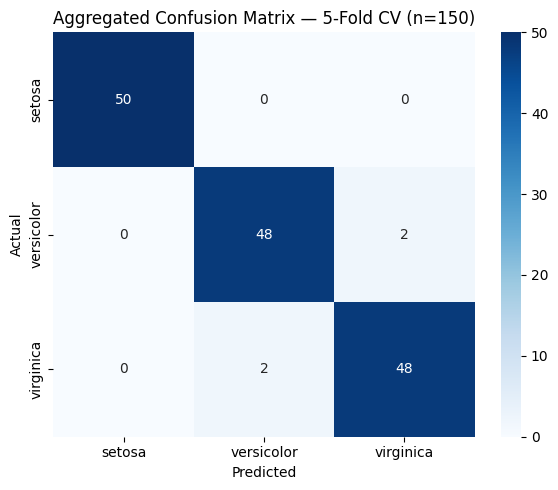

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Aggregate predictions from all folds — every sample was in a val set exactly once.
all_preds   = np.concatenate([r['preds']   for r in fold_results])
all_targets = np.concatenate([r['targets'] for r in fold_results])

cm = confusion_matrix(all_targets, all_preds)
species_names = ['setosa', 'versicolor', 'virginica']

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=species_names, yticklabels=species_names, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Aggregated Confusion Matrix — {K}-Fold CV (n=150)')
plt.tight_layout()
plt.show()